In [1]:
import pandas as pd
import os
import re
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from scipy.stats import ks_2samp

In [2]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/PLM/integrated_data/v1/disgenet/disgenet_info_filtered.pkl", "rb") as f:
    disgenet_info = pickle.load(f)

In [3]:
disgenet_info

,index,disgenet_id,AIR,AOT,CHV,CSP,FMA,GO,HL7V3.0,HPO,...,MSH,NCI,PDQ,SPN,UWDA,primekg_mondo,primekg_orphanet,allDescriptions,numDescriptions,name
0,0,C0000039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Synthetic phospholipid used in liposomes and l...,NaN,NaN,NaN,NaN,NaN,NaN,Synthetic phospholipid used in liposomes and l...,1,"1,2-dipalmitoylphosphatidylcholine"
1,1,C0000052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"In glycogen or amylopectin synthesis, the enzy...",NaN,NaN,NaN,NaN,NaN,NaN,"In glycogen or amylopectin synthesis, the enzy...",1,"1,4-alpha-Glucan Branching Enzyme"
2,2,C0000084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"Found in various tissues, particularly in four...",NaN,NaN,NaN,NaN,NaN,NaN,"Found in various tissues, particularly in four...",1,1-Carboxyglutamic Acid
3,3,C0000096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,A potent cyclic nucleotide phosphodiesterase i...,NaN,NaN,NaN,NaN,NaN,NaN,A potent cyclic nucleotide phosphodiesterase i...,1,1-Methyl-3-isobutylxanthine
4,4,C0000097,NaN,NaN,NaN,"1-methyl-4-phenyl-1,2,5,6-tetrahydropyridine, ...",NaN,NaN,NaN,NaN,...,A dopaminergic neurotoxic compound which produ...,NaN,NaN,NaN,NaN,NaN,NaN,"1-methyl-4-phenyl-1,2,5,6-tetrahydropyridine, ...",2,"1-Methyl-4-phenyl-1,2,3,6-tetrahydropyridine"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238021,238021,CN902090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Short-rib thoracic dysplasia (SRTD) with or wi...,NaN,Short-rib thoracic dysplasia (SRTD) with or wi...,1,short-rib thoracic dysplasia 20 with polydactyly
238022,238022,CN924907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,A congenital hypogonadotropic hypogonadism tha...,"A rare, genetic pituitary hormone deficiency c...",A congenital hypogonadotropic hypogonadism tha...,2,isolated congenital hypogonadotropic hypogonadism
238023,238023,CN924917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,An Orphanet summary for this disease is curren...,An Orphanet summary for this disease is curren...,1,maternally-inherited progressive external opht...
238024,238024,CN924922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Pontocerebellar hypoplasias (PCH) are a rare h...,A rare group of neurodegenerative disorders wi...,Pontocerebellar hypoplasias (PCH) are a rare h...,2,pontocerebellar hypoplasia


In [4]:
relations_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/PLM/integrated_data/v1/protein_disgenet/area_protein_aware_disgenet_centric/protein_disgenet_relations.unified.csv")
relations_df

,seq_id,text_id,num_texts,text_type,seq_type,relation,split
0,P27797,C0036337,3,umls,protein,protein_DisGeNet,CL_val_two_shot
1,P27797,C0036349,3,umls,protein,protein_DisGeNet,CL_val_two_shot
2,Q9UBC3,C0036341,5,umls,protein,protein_DisGeNet,CL_val_two_shot
3,Q96JE9,C0036341,5,umls,protein,protein_DisGeNet,CL_val_two_shot
4,O43759,C0036341,5,umls,protein,protein_DisGeNet,CL_val_two_shot
...,...,...,...,...,...,...,...
52884,Q12794,C1291490,2,umls,protein,protein_DisGeNet,eval_zero_shot
52885,P50336,C0162532,4,umls,protein,protein_DisGeNet,eval_zero_shot
52886,Q93100,C0543514,2,umls,protein,protein_DisGeNet,eval_zero_shot
52887,P35573,C1968739,1,umls,protein,protein_DisGeNet,eval_zero_shot


In [12]:
human_proteins = os.listdir("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/UP000005640_9606_HUMAN_v4")
human_proteins = set([x.split("-")[1] for x in human_proteins if x.startswith("AF-") and x.endswith(".cif.gz")])
len(human_proteins), len(relations_df['seq_id'].unique()), len(set(human_proteins) & set(relations_df['seq_id'].unique()))

(20504, 8480, 8453)

In [14]:
non_disease_human_proteins = list(human_proteins - set(relations_df['seq_id'].unique()))

with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/non_disease_disgenet_proteins.txt", "w") as f:
    f.write("\n".join(non_disease_human_proteins))

print("num non disease human proteins", len(non_disease_human_proteins))
chunk_size = len(non_disease_human_proteins) // 7 + 1
for i in range(7):
    end = min((i+1)*chunk_size, len(non_disease_human_proteins))
    non_disease_human_proteins_chunk = non_disease_human_proteins[i*chunk_size:end]
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/AF2DB_structures_pesto_non_disease/{i}.txt", "w") as f:
        f.write("\n".join(non_disease_human_proteins_chunk))


num non disease human proteins 12051


In [11]:
human_proteins = os.listdir("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/UP000005640_9606_HUMAN_v4")
human_proteins = set([x for x in human_proteins if not x.startswith("AF-") and x.endswith(".pdb")])
len(human_proteins)

14372

In [55]:
proteins_per_disease = relations_df.drop_duplicates(subset=['seq_id', 'text_id']).groupby('text_id').size()
sum(proteins_per_disease > 20)/len(proteins_per_disease), sum(proteins_per_disease > 20)

(0.06082055315244462, 464)

In [15]:
disease_proteins = relations_df['seq_id'].unique().tolist()
with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/AF2DB_structures/disgenet_proteins.txt", "w") as f:
    f.write("\n".join(disease_proteins))

In [7]:
downloaded = os.listdir("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/AF2DB_structures/")
downloaded = [x.split(".")[0] for x in downloaded if x.endswith(".pdb")]
processed = os.listdir("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/AF2DB_structures_pesto/")
processed = [x.replace("_i0.pdb", "") for x in processed if x.endswith("_i0.pdb")]
print(len(disease_proteins), len(downloaded), len(processed))

8480 8479 8337


## Are some diseases more enriched in interactions with certain modalities?

In [66]:
embeddings = {}
for modality in ["protein", "nucleic_acid", "ion", "ligand", "lipid"]:
    fname = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_0_epoch11_step68820/embeddings_PeSTo_80_{modality}.pkl"
    if os.path.exists(fname):
        with open(fname, "rb") as f:
            embeddings_list = pickle.load(f)
            embeddings[modality] = {x['id']: x for x in embeddings_list}
        print(f"Loaded {modality}: {len(embeddings[modality])} embeddings")
    else:
        print(f"Missing {fname}")

Missing /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_0_epoch11_step68820/embeddings_PeSTo_80_protein.pkl
Loaded nucleic_acid: 3683 embeddings
Loaded ion: 2529 embeddings
Loaded ligand: 1969 embeddings
Loaded lipid: 4695 embeddings


In [67]:
interactions = []
for modality, emb in embeddings.items():
    for item_id, item in emb.items():
        interactions.append([item['id'], modality])
interactions_df = pd.DataFrame(interactions, columns=["seq_id", "modality"])


In [68]:
total_modality_counts = interactions_df['modality'].value_counts(normalize=True)
total_modality_counts

modality
lipid           0.364632
nucleic_acid    0.286036
ion             0.196412
ligand          0.152920
Name: proportion, dtype: float64

In [69]:
# Merge DataFrames
merged_df = interactions_df.merge(relations_df, on='seq_id')
merged_df = merged_df.merge(disgenet_info, left_on='text_id', right_on='disgenet_id', how='left')

# Calculate proteins_per_disease
proteins_per_disease = relations_df.drop_duplicates(subset=['seq_id', 'text_id']).groupby('text_id').size()
total_modality_counts = interactions_df['modality'].value_counts(normalize=True)

# Group and aggregate data with seq_id as a list
modality_counts = (
    merged_df
    .groupby(['text_id', 'name', 'modality'])
    .agg(
        count=('seq_id', 'size'), 
        seq_ids=('seq_id', lambda x: list(x))
    )
    .reset_index()
)

# Calculate proportions and log odds ratios
modality_counts['proportion'] = modality_counts['count'] / proteins_per_disease[modality_counts['text_id']].values
modality_counts['expected_proportion'] = total_modality_counts[modality_counts['modality']].values
modality_counts['log_odds_ratio'] = np.log(modality_counts['proportion'] / modality_counts['expected_proportion'])

# Filter by proteins per disease
modality_counts = modality_counts[proteins_per_disease[modality_counts['text_id']].values > 20]

# Sort and display the top results
modality_counts.sort_values(by='log_odds_ratio', ascending=False, inplace=True)
print("number of disease, modality pairs:", len(modality_counts))
print("number of disease, modality pairs with log odds ratio > 0.5:", len(modality_counts[modality_counts['log_odds_ratio'] > 0.5]))
print("number of disease, modality pairs with log odds ratio < -0.5:", len(modality_counts[modality_counts['log_odds_ratio'] < -0.5]))
print("number of unique diseases:", len(modality_counts['text_id'].unique()))
modality_counts.head(30)

number of disease, modality pairs: 1855
number of disease, modality pairs with log odds ratio > 0.5: 728
number of disease, modality pairs with log odds ratio < -0.5: 45
number of unique diseases: 464


,text_id,name,modality,count,seq_ids,proportion,expected_proportion,log_odds_ratio
7568,C0496920,Neoplasm of uncertain or unknown behavior of o...,ligand,21,"[P38398, P27986, P15056, P01116, P60484, Q0346...",0.700000,0.152920,1.521164
6842,C0345958,Large cell lung carcinoma,ligand,18,"[Q16288, Q06187, Q16566, Q8NFD2, P11362, P2932...",0.666667,0.152920,1.472374
4060,C0149782,Squamous cell lung carcinoma,ligand,18,"[P06241, Q8NFD2, P08069, P01116, P11362, P4653...",0.620690,0.152920,1.400915
6193,C0278701,Gastric Adenocarcinoma,ligand,25,"[Q16288, P29322, P06213, P37173, Q9P0L2, Q1653...",0.595238,0.152920,1.359046
4478,C0175704,LEOPARD Syndrome,ligand,13,"[P15056, P01116, P60484, P01112, P04049, P0111...",0.590909,0.152920,1.351746
2724,C0028326,Noonan Syndrome,ligand,13,"[P15056, P01116, P01112, P04049, P01111, P3650...",0.541667,0.152920,1.264735
6206,C0278883,Metastatic melanoma,ligand,28,"[P06241, P29322, P54764, O14965, Q96RG2, P4174...",0.538462,0.152920,1.258800
9120,C1319315,Adenocarcinoma of the large intestine,ligand,49,"[P29597, P17252, P27986, P15056, P04629, P0111...",0.521277,0.152920,1.226365
5232,C0242184,Hypoxia,ligand,17,"[P29475, P55263, O75390, P29474, P63092, P0516...",0.500000,0.152920,1.184692
9236,C1335177,Ovarian Serous Adenocarcinoma,ligand,11,"[Q5S007, O60674, Q9UM73, P04629, Q9P0L2, P0404...",0.500000,0.152920,1.184692


## How closely related are these embeddings?

In [108]:
def get_cosine_similarity(modality, item_ids):
    emb = embeddings[modality]
    emb_vectors = np.array([emb[x]['graph_embedding'] for x in item_ids if x in emb])
    if len(emb_vectors) == 0:
        return None
    similarity_matrix = cosine_similarity(emb_vectors)
    upper_triangle = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
    return upper_triangle if len(upper_triangle) > 0 else None

reference_similarity = {}
for modality, emb in embeddings.items():
    similarity = get_cosine_similarity(modality, emb.keys())
    reference_similarity[modality] = similarity

def analyse_distributions(test, reference):
    if test is None:
        return None
    ks_stat, ks_pval = ks_2samp(test, reference)
    delta_mean = test.mean() - reference.mean()
    delta_median = np.median(test) - np.median(reference)
    return {
        "ks_stat": ks_stat,
        "ks_pval": ks_pval,
        "delta_mean": delta_mean,
        "delta_median": delta_median
    }

In [120]:
for modality, sim in reference_similarity.items():
    print(modality, np.mean(sim), np.median(sim))

nucleic_acid 0.4791208 0.6434038
ion 0.35226783 0.46219534
ligand 0.64022326 0.73430693
lipid 0.36546603 0.54404944


In [109]:
modality_counts['cosine_similarity'] = modality_counts.apply(lambda row: get_cosine_similarity(row['modality'], row['seq_ids']), axis=1)
modality_counts['reference_similarity'] = modality_counts['modality'].map(reference_similarity)
modality_counts_results = modality_counts.apply(lambda row: pd.Series(analyse_distributions(row['cosine_similarity'], row['reference_similarity'])), axis=1)
modality_counts = pd.concat([modality_counts, modality_counts_results], axis=1)

In [ ]:
# with open("disease_embedding_similarity.pkl", "wb") as f:
#     pickle.dump(modality_counts, f)

In [2]:
with open("disease_embedding_similarity.pkl", "rb") as f:
    modality_counts = pickle.load(f)
modality_counts

,text_id,name,modality,count,seq_ids,proportion,expected_proportion,log_odds_ratio,cosine_similarity,reference_similarity,ks_stat,ks_pval,delta_mean,delta_median
7568,C0496920,Neoplasm of uncertain or unknown behavior of o...,ligand,21,"[P38398, P27986, P15056, P01116, P60484, Q0346...",0.700000,0.152920,1.521164,"[0.9937735, 0.91825527, 0.58672696, -0.2421639...","[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.066501,2.976798e-01,0.009169,0.013015
6842,C0345958,Large cell lung carcinoma,ligand,18,"[Q16288, Q06187, Q16566, Q8NFD2, P11362, P2932...",0.666667,0.152920,1.472374,"[0.592732, 0.82083434, 0.77113146, 0.8570055, ...","[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.147883,2.195984e-03,0.101324,0.051942
4060,C0149782,Squamous cell lung carcinoma,ligand,18,"[P06241, Q8NFD2, P08069, P01116, P11362, P4653...",0.620690,0.152920,1.400915,"[0.9795567, 0.6885916, 0.95803946, 0.9037863, ...","[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.147603,2.253223e-03,0.112246,0.043081
6193,C0278701,Gastric Adenocarcinoma,ligand,25,"[Q16288, P29322, P06213, P37173, Q9P0L2, Q1653...",0.595238,0.152920,1.359046,"[0.87415725, 0.6508219, 0.6276107, 0.7574, 0.8...","[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.047849,4.833906e-01,0.017266,-0.003057
4478,C0175704,LEOPARD Syndrome,ligand,13,"[P15056, P01116, P60484, P01112, P04049, P0111...",0.590909,0.152920,1.351746,"[0.4898121, 0.006265234, 0.5445821, 0.64174145...","[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.365719,7.355707e-10,0.007481,0.170082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7658,C0543859,"Amyotrophic Lateral Sclerosis, Guam Form",ligand,2,"[P00390, Q99497]",0.052632,0.152920,-1.066600,[0.4887763],"[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.769996,4.600082e-01,-0.151447,-0.245531
9050,C1292769,Precursor B-cell lymphoblastic leukemia,ligand,1,[P48426],0.047619,0.152920,-1.166683,None,"[0.54180443, 0.93286425, 0.8613273, 0.75092936...",NaN,NaN,NaN,NaN
8920,C1260899,"Anemia, Diamond-Blackfan",lipid,3,"[P01588, P15976, Q9NZK5]",0.100000,0.364632,-1.293718,"[0.5702623, 0.95479846, 0.7241302]","[0.90127987, -0.104851276, 0.866094, 0.5055344...",0.516637,2.956401e-01,0.384264,0.180081
1237,C0015967,Fever,nucleic_acid,2,"[P28223, P09429]",0.074074,0.286036,-1.351052,[-0.49493623],"[0.70340276, 0.6522855, 0.97132295, 0.9684479,...",0.958025,8.394958e-02,-0.974057,-1.138340


In [10]:
modality_counts[(modality_counts.modality == 'ion') & (modality_counts.delta_mean > 0) & (modality_counts.delta_median > 0)].sort_values(by='ks_pval', ascending=True).head(30)

,text_id,name,modality,count,seq_ids,proportion,expected_proportion,log_odds_ratio,cosine_similarity,reference_similarity,ks_stat,ks_pval,delta_mean,delta_median
4152,C0152013,Adenocarcinoma of lung (disorder),ion,57,"[O15527, Q09472, P48050, P04179, Q16566, Q9UM7...",0.285000,0.196412,0.372275,"[-0.30819845, 0.770644, 0.7697954, 0.8397286, ...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.139214,1.985281e-27,0.141402,0.192733
3214,C0035334,Retinitis Pigmentosa,ion,34,"[Q9BXC9, Q9H0F7, Q8N157, P78363, P51955, Q9NRG...",0.323810,0.196412,0.499941,"[0.7295626, 0.8925915, 0.77363086, 0.7584096, ...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.202343,1.299437e-20,0.206886,0.229731
12669,C2239176,Liver carcinoma,ion,145,"[P09467, P15104, P08183, P04637, Q13609, P0337...",0.301455,0.196412,0.428408,"[-0.20963094, -0.20999174, 0.28871202, -0.6016...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.045422,4.281141e-19,0.033767,0.044414
16552,C4277690,Ciliopathies,ion,36,"[Q9BXC9, Q9H0F7, P13569, Q96PY6, Q9P2H3, Q96RI...",0.336449,0.196412,0.538231,"[0.7295626, 0.5546797, 0.83776546, 0.46807536,...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.164740,2.072115e-15,0.147906,0.155946
7845,C0678222,Breast Carcinoma,ion,148,"[Q9UBC3, P08183, O95259, P11473, P08254, P0463...",0.296000,0.196412,0.410145,"[0.58332914, 0.51091665, 0.5635545, 0.80639887...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.037795,6.840478e-14,0.033920,0.054375
1118,C0014175,Endometriosis,ion,51,"[Q13330, Q5S007, O95267, Q13285, P04150, P0823...",0.331169,0.196412,0.522414,"[0.9335375, 0.8293254, 0.9279613, 0.84401363, ...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.109361,1.003515e-13,0.101240,0.126412
5957,C0269102,Endometrioma,ion,51,"[Q13330, Q5S007, O95267, Q13285, P04150, P0823...",0.331169,0.196412,0.522414,"[0.9335375, 0.8293254, 0.9279613, 0.84401363, ...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.109361,1.003515e-13,0.101240,0.126412
6841,C0345958,Large cell lung carcinoma,ion,12,"[Q06187, Q16566, Q8NFD2, Q96PY6, Q8IUG5, Q1683...",0.444444,0.196412,0.816611,"[0.57258, 0.63971, 0.6883241, 0.71799594, 0.74...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.460676,2.449740e-13,0.412582,0.430169
83,C0001973,"Alcoholic Intoxication, Chronic",ion,78,"[P15104, P04637, P17752, Q01959, Q09472, Q1411...",0.282609,0.196412,0.363849,"[0.28826454, 0.043496832, 0.7635464, -0.184820...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.069517,4.737426e-13,0.071901,0.100286
913,C0011581,Depressive disorder,ion,73,"[P48454, P15104, P08183, P17752, Q01959, P3839...",0.252595,0.196412,0.251574,"[0.5953395, 0.5233576, 0.81680244, 0.8933981, ...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.072298,2.211521e-12,0.076119,0.103210


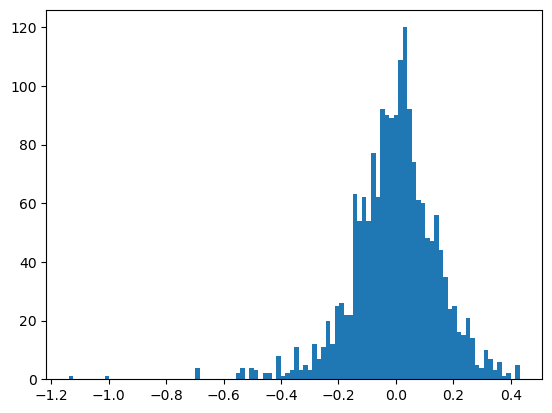

In [7]:
plt.hist(modality_counts.delta_median, bins=100)
plt.show()

In [131]:
modality_counts[modality_counts.name == "Alzheimer's Disease"]

,text_id,name,modality,count,seq_ids,proportion,expected_proportion,log_odds_ratio,cosine_similarity,reference_similarity,ks_stat,ks_pval,delta_mean,delta_median
103,C0002395,Alzheimer's Disease,lipid,60,"[P10082, P41159, P01344, P06276, P22303, P0685...",0.674157,0.364632,0.614575,"[0.75778913, 0.9690424, 0.7163625, 0.68970114,...","[0.90127987, -0.104851276, 0.866094, 0.5055344...",0.063896,0.000001,0.067687,0.068615
102,C0002395,Alzheimer's Disease,ligand,24,"[P06276, P22303, P29474, P05164, P27338, O1455...",0.269663,0.152920,0.567257,"[0.9811211, -0.19476166, 0.51603687, 0.5303447...","[0.54180443, 0.93286425, 0.8613273, 0.75092936...",0.049997,0.479935,0.004683,-0.007334
101,C0002395,Alzheimer's Disease,ion,20,"[P56817, P03372, P04179, P12821, P29474, P0516...",0.224719,0.196412,0.134637,"[0.51424104, 0.75863475, 0.89268696, 0.9376309...","[-0.6823862, 0.2976014, -0.8262497, -0.6712456...",0.167278,0.000041,0.153481,0.199198
104,C0002395,Alzheimer's Disease,nucleic_acid,25,"[P03372, P05019, O14863, O95185, O96008, P0074...",0.280899,0.286036,-0.018123,"[0.16067693, -0.33249635, -0.19188938, -0.1560...","[0.70340276, 0.6522855, 0.97132295, 0.9684479,...",0.056399,0.284854,-0.025175,0.038302


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


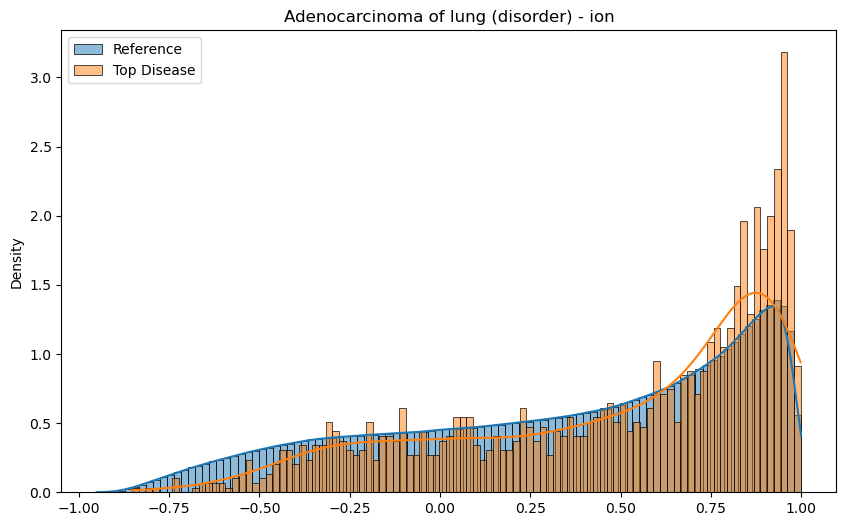

In [14]:
row_idx = 4152
reference_data = modality_counts.loc[row_idx]['reference_similarity']
top_disease_data = modality_counts.loc[row_idx]['cosine_similarity']
modality = modality_counts.loc[row_idx]['modality']
disease = modality_counts.loc[row_idx]['name']

# Create a figure with density plots including KDE
plt.figure(figsize=(10, 6))
sns.histplot(reference_data, bins=100, kde=True, stat="density", alpha=0.5, label='Reference')
sns.histplot(top_disease_data, bins=100, kde=True, stat="density", alpha=0.5, label='Top Disease')
plt.title(f'{disease} - {modality}')

# Add a legend and show the plot
plt.legend()
plt.show()

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


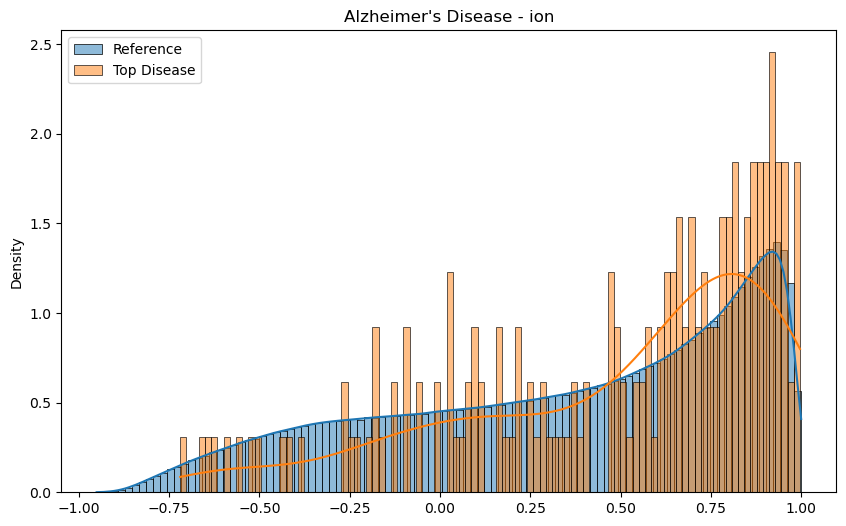

In [133]:
row_idx = 101
reference_data = modality_counts.loc[row_idx]['reference_similarity']
top_disease_data = modality_counts.loc[row_idx]['cosine_similarity']
modality = modality_counts.loc[row_idx]['modality']
disease = modality_counts.loc[row_idx]['name']

# Create a figure with density plots including KDE
plt.figure(figsize=(10, 6))
sns.histplot(reference_data, bins=100, kde=True, stat="density", alpha=0.5, label='Reference')
sns.histplot(top_disease_data, bins=100, kde=True, stat="density", alpha=0.5, label='Top Disease')
plt.title(f'{disease} - {modality}')

# Add a legend and show the plot
plt.legend()
plt.show()

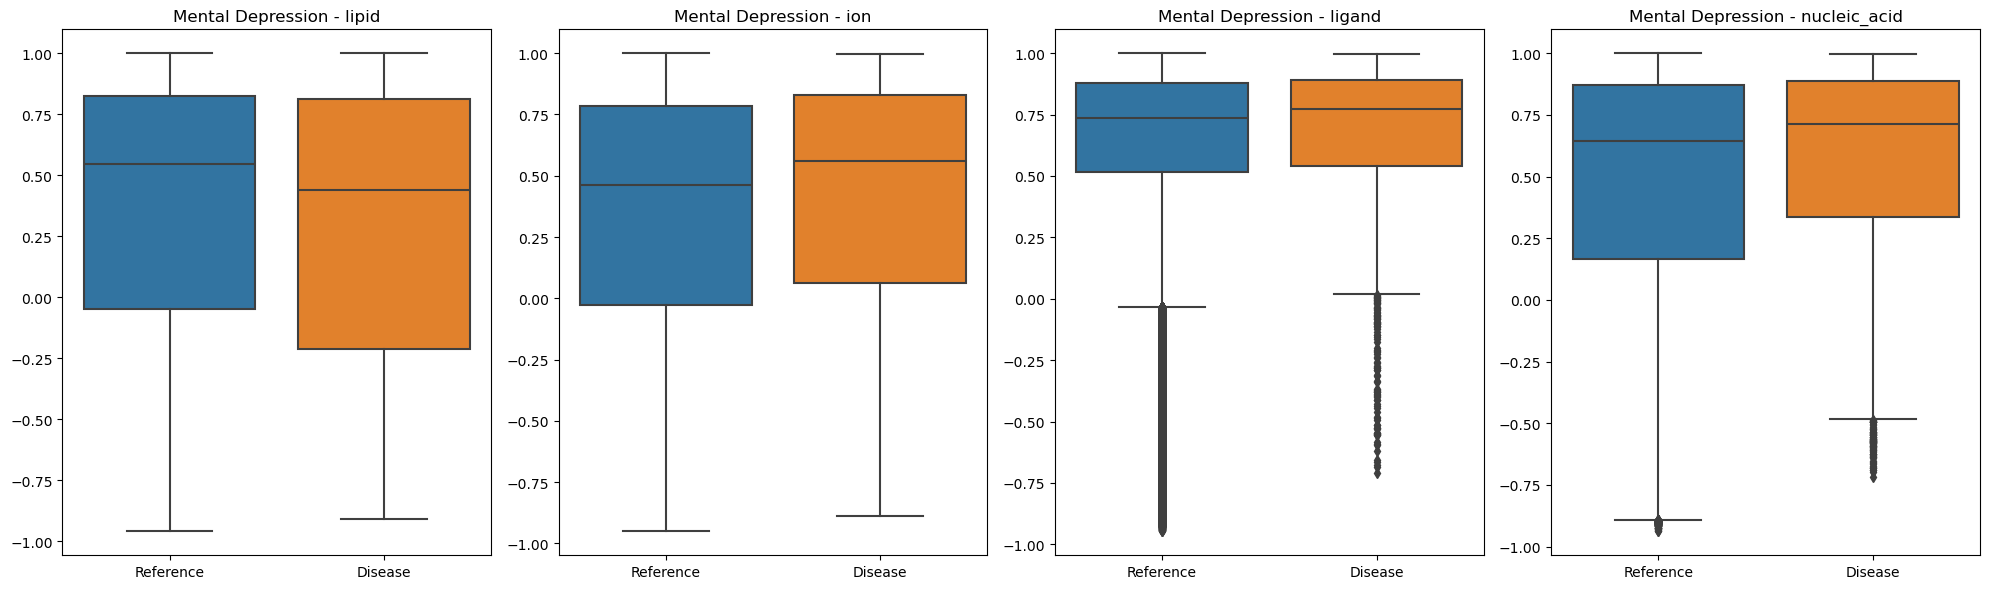

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for Alzheimer's Disease
disease_name = "Mental Depression"
alzheimer_data = modality_counts[modality_counts.name == disease_name]

# Get unique modalities present in the filtered data
unique_modalities = alzheimer_data['modality'].unique()

# Set up figure with a single row and four columns
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 6), sharex=True)

# Loop over each modality and create a box plot
for i, modality in enumerate(unique_modalities):
    # Extract data corresponding to the current modality
    current_data = alzheimer_data[alzheimer_data['modality'] == modality]
    
    # Prepare data for the box plot
    reference_data = current_data['reference_similarity'].explode()
    top_disease_data = current_data['cosine_similarity'].explode()
    data = [reference_data.dropna(), top_disease_data.dropna()]
    labels = ['Reference', 'Disease']
    
    # Plot using shared subplot axes
    sns.boxplot(data=data, ax=axes[i])
    axes[i].set_title(f'{disease_name} - {modality}')
    axes[i].set_xticklabels(labels)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [94]:
np.median(reference_data), np.median(top_disease_data)
np.mean(reference_data), np.mean(top_disease_data)


(0.64022326, 0.6493924)

In [96]:
ks_2samp(reference_data, top_disease_data)

KstestResult(statistic=0.06650067922720881, pvalue=0.29767980531793814, statistic_location=0.88710153, statistic_sign=1)